In [93]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "gpt2"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    output_attentions=True
)

model.eval()

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 17504.85it/s]


GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [102]:
def get_bank_attention(text, layer_idx=0, head_idx=0):
    # encode: text -> token ids
    input_ids = tokenizer.encode(text, return_tensors="pt")

    with torch.no_grad():
        outputs = model(input_ids=input_ids)

    attentions = outputs.attentions

    # decode each token id separately for clean labels
    labels = [tokenizer.decode([tok_id]) for tok_id in input_ids[0]]

    print(labels)

    clean_labels = [label.strip() for label in labels]
    bank_idx = clean_labels.index("bank")

    attn_matrix = attentions[layer_idx][0, head_idx]
    bank_attention = attn_matrix[bank_idx]

    return labels, bank_attention, attn_matrix

In [103]:
text_1 = "He deposited money in the bank."
text_2 = "He sat beside the river bank."

labels_1, bank_attention_1, attn_matrix_1 = get_bank_attention(text_1)
labels_2, bank_attention_2, attn_matrix_2 = get_bank_attention(text_2)

print(bank_attention_1)
print(bank_attention_2)

['He', ' deposited', ' money', ' in', ' the', ' bank', '.']
['He', ' sat', ' beside', ' the', ' river', ' bank', '.']
tensor([0.3759, 0.1494, 0.1559, 0.1018, 0.1169, 0.1000, 0.0000])
tensor([0.2644, 0.1121, 0.1231, 0.0810, 0.3491, 0.0703, 0.0000])


In [104]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_bank_attention(labels, bank_attention, title):
    display_labels = [label.strip() if label.strip() else label for label in labels]

    values = bank_attention.detach().cpu().numpy()

    df = pd.DataFrame(
        [values],
        columns=display_labels,
        index=["bank"]
    )

    plt.figure(figsize=(10, 2.5))
    sns.heatmap(
        df,
        annot=True,
        fmt=".2f",
        cmap="viridis",
        cbar=True
    )

    plt.title(title)
    plt.xlabel("Key tokens attended to by 'bank'")
    plt.ylabel("Query token")
    plt.tight_layout()
    plt.show()

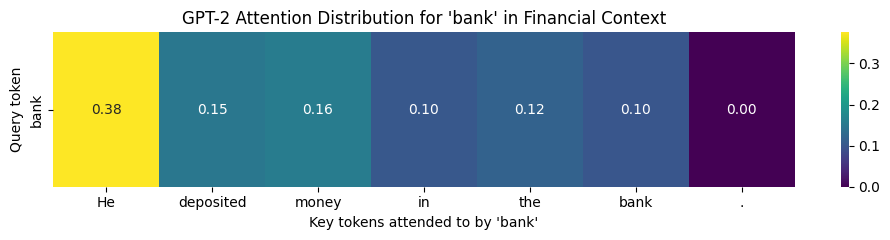

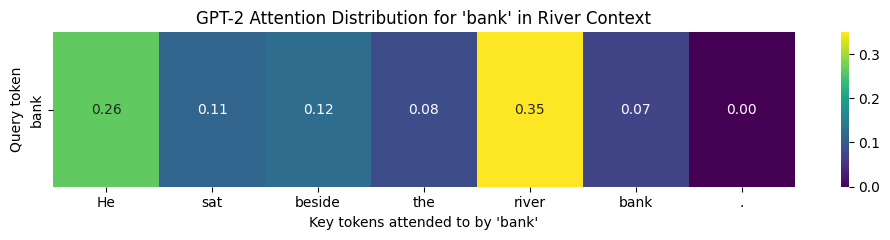

In [105]:
plot_bank_attention(
    labels_1,
    bank_attention_1,
    "GPT-2 Attention Distribution for 'bank' in Financial Context"
)

plot_bank_attention(
    labels_2,
    bank_attention_2,
    "GPT-2 Attention Distribution for 'bank' in River Context"
)